# Identificar fronteras no lineales

In [39]:
from sklearn.datasets import make_circles, make_blobs
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC

In [26]:
X, Y = make_circles(100, factor = 0.1, noise = 0.1, random_state = 0)

In [27]:
def plt_svc(model, ax = None, plot_support = True):
    if ax == None:
        ax = plt.gca()

    # Plot de la función de decisión para una clasificación en 2D con SVC

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Generamos la parrilla de puntos para evaluar el modelo:

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(yy, xx)

    # Evaluar el modelo:

    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # Representamos las frontereas y los márgenes del SVC

    ax.contour(X, Y, P, colors = 'k', levels = [-1, 0, 1],
               alpha = 0.5, linestyles = ['--', '-', '--']
               )

    print(model.support_vectors_)

    if plot_support == True:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s = 300, linewidth = 1, facecolors = 'black'
                   )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

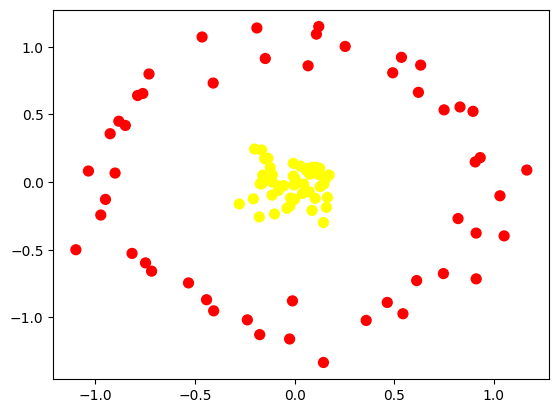

In [28]:
plt.scatter(X[:,0], X[:, 1], c = Y, s = 50, cmap = 'autumn')

[[-9.49575361e-01 -1.28130352e-01]
 [ 9.32149730e-01  1.80812148e-01]
 [-4.08679248e-01  7.32259917e-01]
 [ 1.21578633e-01  1.15057745e+00]
 [ 4.92870432e-01  8.08229304e-01]
 [-8.16072717e-01 -5.27369282e-01]
 [-8.82561586e-01  4.50116282e-01]
 [-9.01362740e-01  6.67509461e-02]
 [-4.42070911e-01 -8.69788735e-01]
 [ 6.33186666e-01  8.65056203e-01]
 [ 7.47388187e-01 -6.76523545e-01]
 [ 8.30760472e-01  5.55363961e-01]
 [ 9.12098589e-01 -7.15484151e-01]
 [ 1.05235514e+00 -3.97701028e-01]
 [ 6.21947127e-01  6.63634244e-01]
 [-9.73157971e-01 -2.43700046e-01]
 [-7.30977035e-01  7.99252008e-01]
 [ 1.16614005e+00  8.89245560e-02]
 [ 5.44097789e-01 -9.73433771e-01]
 [ 3.59668868e-01 -1.02284615e+00]
 [ 8.96070944e-01  5.23143672e-01]
 [-1.89284796e-01  1.13939190e+00]
 [-4.64404413e-01  1.07276126e+00]
 [ 4.65427252e-01 -8.89946145e-01]
 [-2.49458126e-02 -1.16013548e+00]
 [ 7.50849695e-01  5.34001857e-01]
 [ 9.07184082e-01  1.49072192e-01]
 [-4.06229358e-01 -9.51987486e-01]
 [-7.48541021e-01 -5

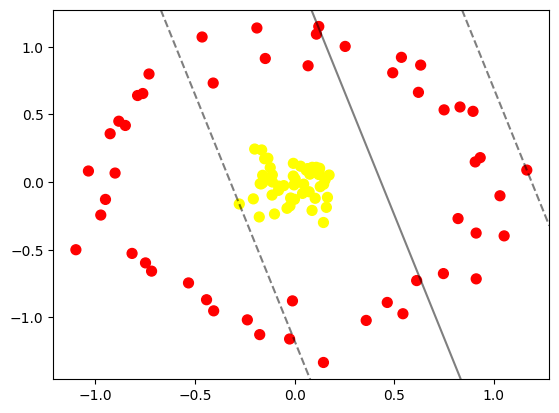

In [29]:
plt.scatter(X[:,0], X[:, 1], c = Y, s = 50, cmap = 'autumn')
plt_svc(SVC(kernel = 'linear').fit(X, Y), plot_support = False)

In [30]:
r = np.exp(-(X ** 2).sum(1))
r

array([0.39927265, 0.9824255 , 0.40592123, 0.99769489, 0.97216154,
       0.97411733, 0.49498723, 0.98980035, 0.98619619, 0.99956458,
       0.9809366 , 0.94971078, 0.98392734, 0.26220993, 0.40813557,
       0.38903225, 0.3747412 , 0.44179448, 0.38598409, 0.3168751 ,
       0.36194131, 0.98563048, 0.36839775, 0.9847685 , 0.26084174,
       0.28206508, 0.43725941, 0.94138512, 0.98038293, 0.9853973 ,
       0.97888865, 0.90671412, 0.99145438, 0.9739485 , 0.98227021,
       0.36552297, 0.30939664, 0.9764735 , 0.9050038 , 0.99276484,
       0.25466911, 0.97656002, 0.28833978, 0.30864117, 0.34074447,
       0.26341023, 0.25500091, 0.36471952, 0.26013966, 0.42787112,
       0.9782628 , 0.98025264, 0.4294691 , 0.34256205, 0.39957025,
       0.96074607, 0.29861557, 0.27182884, 0.37320348, 0.98888731,
       0.34270326, 0.38705807, 0.95212942, 0.98958211, 0.90182605,
       0.94340389, 0.43193225, 0.96179123, 0.4245156 , 0.89557571,
       0.36427427, 0.23316207, 0.34167036, 0.9752803 , 0.97862

In [31]:
from mpl_toolkits import mplot3d

In [32]:
def plot_3D(elev = 30, azim = 30, X = X, Y = Y, r = r):
    ax = plt.subplot(projection = '3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c = Y, s = 50, cmap = 'autumn')
    ax.view_init(elev = elev, azim = azim)

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

In [33]:
from ipywidgets import interact, fixed

interactive(children=(Dropdown(description='elev', index=4, options=(-90, -60, -30, 0, 30, 60, 90), value=30),…

<function __main__.plot_3D(elev=30, azim=30, X=array([[-9.49575361e-01, -1.28130352e-01],
       [ 1.28860852e-01, -3.35507154e-02],
       [ 9.32149730e-01,  1.80812148e-01],
       [ 4.55389138e-02, -1.52962218e-02],
       [-1.67502183e-01, -1.32784256e-02],
       [ 1.25722505e-01,  1.02065522e-01],
       [-4.08679248e-01,  7.32259917e-01],
       [-8.07924621e-02, -6.10295433e-02],
       [ 6.69885738e-02,  9.70180142e-02],
       [-2.93139712e-03, -2.06621508e-02],
       [-6.11267963e-03,  1.38600460e-01],
       [ 8.77414191e-02, -2.09521414e-01],
       [-4.52573414e-04, -1.27291071e-01],
       [ 1.21578633e-01,  1.15057745e+00],
       [ 4.92870432e-01,  8.08229304e-01],
       [-8.16072717e-01, -5.27369282e-01],
       [-8.82561586e-01,  4.50116282e-01],
       [-9.01362740e-01,  6.67509461e-02],
       [-4.42070911e-01, -8.69788735e-01],
       [ 6.33186666e-01,  8.65056203e-01],
       [ 7.47388187e-01, -6.76523545e-01],
       [ 6.69179520e-02,  9.99787569e-02],
       

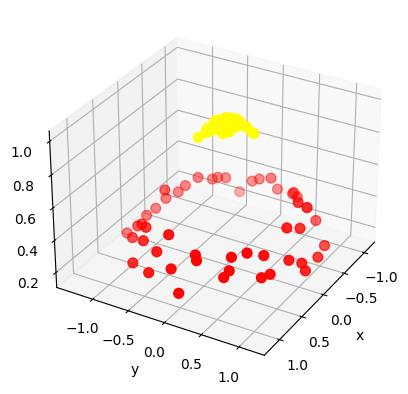

In [34]:
interact(plot_3D, elev = [-90, -60, -30, 0, 30, 60, 90],
         azim = [-180, -150, -120, -90, -60, -30, 0,
                 30, 60, 90, 120, 150, 180],
         X = fixed(X), Y = fixed(Y), r = fixed(r)
         )

## Radial basis function

In [35]:
rbf = SVC(kernel = 'rbf', C = 1E6)
rbf.fit(X, Y)

SVC(C=1000000.0)

[[-0.40867925  0.73225992]
 [-0.90136274  0.06675095]
 [ 0.62194713  0.66363424]
 [-0.53262577 -0.74551749]
 [-0.01059175 -0.87830074]
 [ 0.06782759  0.86000564]
 [ 0.82087304 -0.26971282]
 [ 0.61304799 -0.72820082]
 [-0.20035062  0.24428624]
 [ 0.14497035 -0.29878438]]


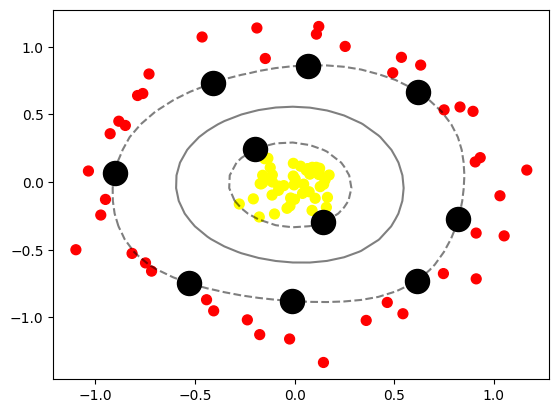

In [36]:
plt.scatter(X[:, 0], X[:,1], c = Y, s = 50, cmap = 'autumn')
plt_svc(rbf)
plt.scatter(rbf.support_vectors_[:, 0], rbf.support_vectors_[:, 1],
            s = 300, lw = 1, facecolors = 'none'
            )

## Ajustar los parámetros en SVM

In [41]:
X, Y = make_blobs(n_samples = 100, centers = 2,
                  random_state = 0, cluster_std = 1.2)

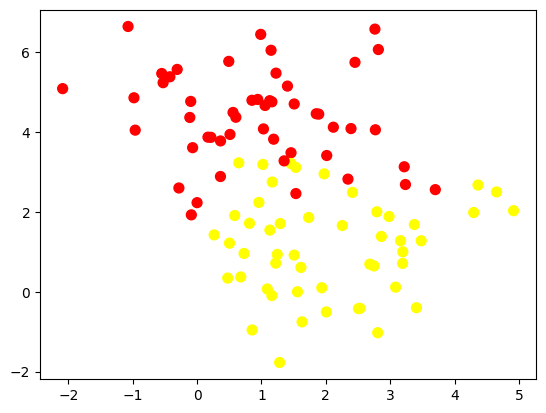

In [42]:
plt.scatter(X[:,0], X[:, 1], c = Y, s = 50, cmap = 'autumn')

In [44]:
# Cambiamos el cluster_std:

X, Y = make_blobs(n_samples = 100, centers = 2,
                  random_state = 0, cluster_std = 0.8)

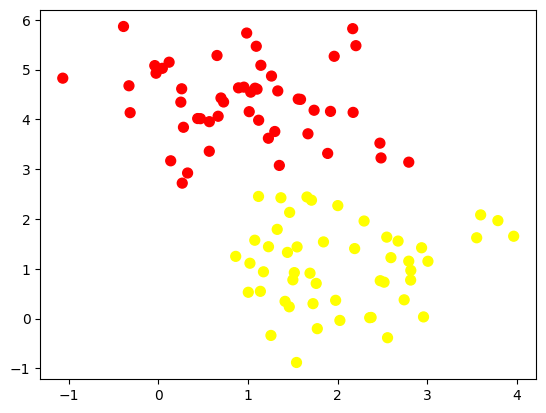

In [45]:
plt.scatter(X[:,0], X[:, 1], c = Y, s = 50, cmap = 'autumn')

[[0.26604148 2.71915015]
 [2.79207378 3.14029479]
 [1.1167688  2.45256061]
 [1.36628697 2.42571562]]
[[0.26604148 2.71915015]
 [1.34880003 3.07479238]
 [1.88779063 3.31592667]
 [0.13742771 3.16777298]
 [2.79207378 3.14029479]
 [2.48279064 3.22558008]
 [2.47031647 3.52196502]
 [1.66781904 3.71005531]
 [0.32575305 2.92276125]
 [0.56762597 3.35928158]
 [3.59362114 2.08207549]
 [1.46361712 2.13207534]
 [2.29385806 1.95877238]
 [1.70714468 2.37707464]
 [2.00067424 2.26833784]
 [1.1167688  2.45256061]
 [1.65684156 2.4412893 ]
 [1.36628697 2.42571562]
 [1.32500974 1.79127669]
 [1.07491911 1.57315404]]


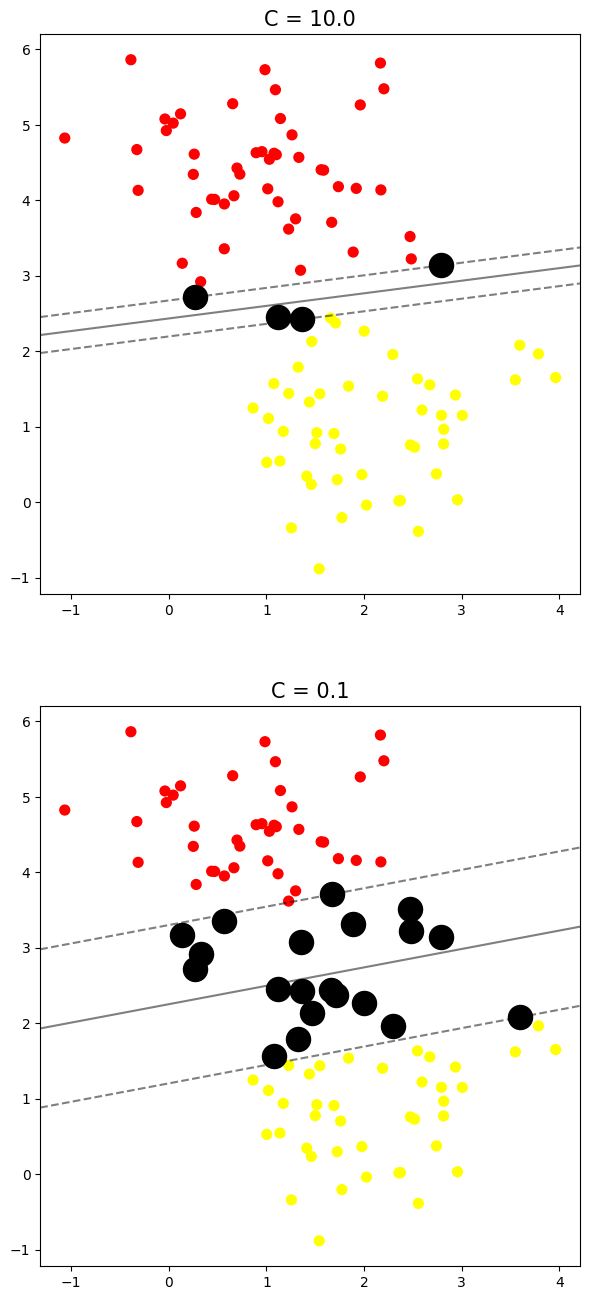

In [51]:
fig, ax = plt.subplots(2, 1, figsize = (6, 16))
fig.subplots_adjust(left = 0.05, right = 0.95, wspace = 0.1)

for ax_i, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel = 'linear', C = C)
    model.fit(X, Y)
    ax_i.scatter(X[:, 0], X[:, 1], c = Y, s = 50, cmap = 'autumn')
    plt_svc(model, ax_i)
    ax_i.set_title('C = {}'.format(C), size = 15)